In [1]:
# Lets do the necessary imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/ingledarshan/BK_Birla/main/titanic.csv")
df.shape

(891, 12)

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [5]:
df.drop(['Cabin'], axis=1, inplace=True)
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [6]:
df.Embarked.fillna(df.Embarked.mode()[0], inplace=True)
df.isna().sum().sort_values(ascending=False)

Age            177
Survived         0
PassengerId      0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

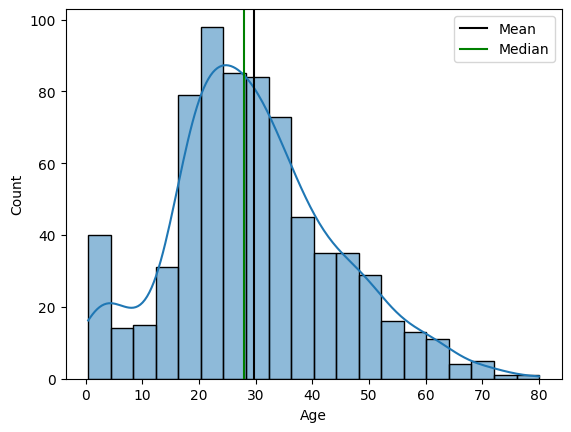

In [7]:
%matplotlib inline
sns.histplot(df.Age, kde=True)
plt.axvline(df.Age.mean(), color='black', label='Mean')
plt.axvline(df.Age.median(), color='green', label='Median')
plt.legend()
plt.show()

In [8]:
df.Age.skew()

np.float64(0.38910778230082704)

In [9]:
# As a general rule of thumb:

# If skewness is less than -1 or greater than 1, the distribution is highly skewed.
# If skewness is between -1 and -0.5 or between 0.5 and 1, the distribution is moderately skewed.
# If skewness is between -0.5 and 0.5, the distribution is approximately symmetric.

In [10]:
df.Age.fillna(df.Age.mean(), inplace=True)
df.isna().sum().sort_values(ascending=False)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [11]:
df['FamilySize']  = df['SibSp'] + df['Parch'] + 1
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [12]:
df['GenderClass'] = df.apply(lambda x: 'child' if x['Age'] < 15 else x['Sex'],
                             axis=1)
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,GenderClass
702,703,0,3,"Barbara, Miss. Saiide",female,18.000000,0,1,2691,14.4542,C,2,female
430,431,1,1,"Bjornstrom-Steffansson, Mr. Mauritz Hakan",male,28.000000,0,0,110564,26.5500,S,1,male
38,39,0,3,"Vander Planke, Miss. Augusta Maria",female,18.000000,2,0,345764,18.0000,S,3,female
336,337,0,1,"Pears, Mr. Thomas Clinton",male,29.000000,1,0,113776,66.6000,S,2,male
597,598,0,3,"Johnson, Mr. Alfred",male,49.000000,0,0,LINE,0.0000,S,1,male
601,602,0,3,"Slabenoff, Mr. Petco",male,29.699118,0,0,349214,7.8958,S,1,male
363,364,0,3,"Asim, Mr. Adola",male,35.000000,0,0,SOTON/O.Q. 3101310,7.0500,S,1,male
692,693,1,3,"Lam, Mr. Ali",male,29.699118,0,0,1601,56.4958,S,1,male
687,688,0,3,"Dakic, Mr. Branko",male,19.000000,0,0,349228,10.1708,S,1,male
626,627,0,2,"Kirkland, Rev. Charles Leonard",male,57.000000,0,0,219533,12.3500,Q,1,male


In [13]:
df.drop(['PassengerId', 'Ticket'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,GenderClass
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,2,male
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,2,female
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,1,female
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,2,female
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1,male


In [14]:
df.drop(['Name'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,GenderClass
0,0,3,male,22.0,1,0,7.2500,S,2,male
1,1,1,female,38.0,1,0,71.2833,C,2,female
2,1,3,female,26.0,0,0,7.9250,S,1,female
3,1,1,female,35.0,1,0,53.1000,S,2,female
4,0,3,male,35.0,0,0,8.0500,S,1,male


In [15]:
df.drop(['SibSp', 'Parch'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,GenderClass
0,0,3,male,22.0,7.2500,S,2,male
1,1,1,female,38.0,71.2833,C,2,female
2,1,3,female,26.0,7.9250,S,1,female
3,1,1,female,35.0,53.1000,S,2,female
4,0,3,male,35.0,8.0500,S,1,male


In [16]:
df.drop(['Sex'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Age,Fare,Embarked,FamilySize,GenderClass
0,0,3,22.0,7.2500,S,2,male
1,1,1,38.0,71.2833,C,2,female
2,1,3,26.0,7.9250,S,1,female
3,1,1,35.0,53.1000,S,2,female
4,0,3,35.0,8.0500,S,1,male


In [17]:
# one hot encoding
df = pd.get_dummies(df, columns=['Embarked', 'GenderClass'], drop_first=True, dtype=int)
df.head()

,Survived,Pclass,Age,Fare,FamilySize,Embarked_Q,Embarked_S,GenderClass_female,GenderClass_male
0,0,3,22.0,7.2500,2,0,1,0,1
1,1,1,38.0,71.2833,2,0,0,1,0
2,1,3,26.0,7.9250,1,0,1,1,0
3,1,1,35.0,53.1000,2,0,1,1,0
4,0,3,35.0,8.0500,1,0,1,0,1


In [18]:
X = df.loc[ : , df.columns != 'Survived' ]
X.head()

,Pclass,Age,Fare,FamilySize,Embarked_Q,Embarked_S,GenderClass_female,GenderClass_male
0,3,22.0,7.2500,2,0,1,0,1
1,1,38.0,71.2833,2,0,0,1,0
2,3,26.0,7.9250,1,0,1,1,0
3,1,35.0,53.1000,2,0,1,1,0
4,3,35.0,8.0500,1,0,1,0,1


In [19]:
a = df.iloc[ : , 1:]
a

,Pclass,Age,Fare,FamilySize,Embarked_Q,Embarked_S,GenderClass_female,GenderClass_male
0,3,22.000000,7.2500,2,0,1,0,1
1,1,38.000000,71.2833,2,0,0,1,0
2,3,26.000000,7.9250,1,0,1,1,0
3,1,35.000000,53.1000,2,0,1,1,0
4,3,35.000000,8.0500,1,0,1,0,1
...,...,...,...,...,...,...,...,...
886,2,27.000000,13.0000,1,0,1,0,1
887,1,19.000000,30.0000,1,0,1,1,0
888,3,29.699118,23.4500,4,0,1,1,0
889,1,26.000000,30.0000,1,0,0,0,1


In [20]:
y = df.Survived
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.20,
                                                    random_state=1)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 8), (179, 8), (712,), (179,))

In [23]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[['Age','Fare']] = sc.fit_transform(X_train[['Age','Fare']])
X_test[['Age','Fare']] = sc.transform(X_test[['Age','Fare']])

In [24]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred_train = logreg.predict(X_train)
y_pred_test = logreg.predict(X_test)

from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Train Accuracy: 83.43%
Test Accuracy: 79.89%


In [25]:
# Now we want to understand "Stacking" and then apply it to the above dataset.

# What is Stacking?
# Stacking, also known as stacked generalization, is an ensemble learning technique that combines multiple machine learning models to improve predictive performance. The idea is to train several base models (also called level-0 models) on the training data and then use their predictions as input features for a higher-level model (called the meta-model or level-1 model) that makes the final prediction. The meta-model learns to weigh the predictions of the base models, allowing it to capture complex relationships and improve overall accuracy. Stacking can be used for both classification and regression tasks and is often more effective than using individual models alone.
# In simple words: Stacking is like having a team of experts (base models) who each give their opinion on a problem, and then having a manager (meta-model) who listens to all the experts and makes the final decision based on their advice. This way, the manager can make a better decision than any single expert alone.
# Eg: If we have 3 base models like Logistic Regression, Decision Tree and KNN, we can train these models on the training data and then use their predictions as input features for a meta-model like Random Forest, which will learn to combine the predictions of the base models to make a final prediction.

# Advantages of Stacking:
# 1. Improved Performance: Stacking can often lead to better predictive performance than using individual models alone, as it leverages the strengths of multiple models.
# 2. Flexibility: Stacking allows you to combine different types of models (e.g., linear, tree-based, neural networks) to capture various patterns in the data.
# 3. Reduced Overfitting: By combining multiple models, stacking can help reduce the risk of overfitting that may occur with a single model, especially if the base models are diverse and not highly correlated.
# 4. Better Generalization: Stacking can improve the generalization ability of the model, as the meta-model learns to weigh the predictions of the base models based on their performance on the training data.
# 5. Versatility: Stacking can be applied to both classification and regression problems, making it a versatile technique for various machine learning tasks.

# Disadvantages of Stacking:
# 1. Complexity: Stacking can be more complex to implement and interpret than using a single model, as it involves training multiple models and a meta-model.
# 2. Computational Cost: Training multiple models and a meta-model can be computationally expensive, especially if the base models are complex or if the dataset is large.
# 3. Risk of Overfitting: If not properly tuned, stacking can lead to overfitting, especially if the base models are highly correlated or if the meta-model is too complex.
# 4. Data Leakage: If the predictions of the base models are not properly separated from the training data used for the meta-model, it can lead to data leakage and biased performance estimates.
# 5. Hyperparameter Tuning: Stacking may require careful hyperparameter tuning for both the base models and the meta-model to achieve optimal performance, which can be time-consuming and require expertise in machine learning.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier


base_models = [
    ('logreg', LogisticRegression()), 
    ('dt', DecisionTreeClassifier()),
    ('knn', KNeighborsClassifier())
]
meta_model = RandomForestClassifier()

stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

stacking_clf.fit(X_train, y_train)

# Now we will make predictions using the StackingClassifier on the training and testing data.
y_pred_train_stack = stacking_clf.predict(X_train)
y_pred_test_stack = stacking_clf.predict(X_test)

# Now we will evaluate the performance of the StackingClassifier using accuracy score.
train_accuracy_stack = accuracy_score(y_train, y_pred_train_stack)
test_accuracy_stack = accuracy_score(y_test, y_pred_test_stack)

print(f"Stacking Train Accuracy: {train_accuracy_stack*100:.2f}%")
print(f"Stacking Test Accuracy: {test_accuracy_stack*100:.2f}%")

Stacking Train Accuracy: 81.18%
Stacking Test Accuracy: 77.65%


In [27]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable


In [28]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier

base_models = [
    ('svm', SVC(probability=True)),
    ('rf', RandomForestClassifier()),('cat',CatBoostClassifier())
]
meta_model = GradientBoostingClassifier()

stacking_clf_2 = StackingClassifier(estimators=base_models, final_estimator=meta_model,cv=3)
stacking_clf_2.fit(X_train, y_train)

y_pred_train_stack_2 = stacking_clf_2.predict(X_train)
y_pred_test_stack_2 = stacking_clf_2.predict(X_test)

train_accuracy_stack_2 = accuracy_score(y_train, y_pred_train_stack_2)
test_accuracy_stack_2 = accuracy_score(y_test, y_pred_test_stack_2)

print(f"Stacking Train Accuracy (SVM + RF+cat): {train_accuracy_stack_2*100:.2f}%")
print(f"Stacking Test Accuracy (SVM + RF+cat): {test_accuracy_stack_2*100:.2f}%")


Learning rate set to 0.008911
0:	learn: 0.6862550	total: 139ms	remaining: 2m 18s
1:	learn: 0.6802543	total: 141ms	remaining: 1m 10s
2:	learn: 0.6737676	total: 143ms	remaining: 47.4s
3:	learn: 0.6671987	total: 145ms	remaining: 36s
4:	learn: 0.6608927	total: 147ms	remaining: 29.3s
5:	learn: 0.6549901	total: 151ms	remaining: 24.9s
6:	learn: 0.6487723	total: 153ms	remaining: 21.7s
7:	learn: 0.6427836	total: 155ms	remaining: 19.2s
8:	learn: 0.6374633	total: 157ms	remaining: 17.3s
9:	learn: 0.6317538	total: 159ms	remaining: 15.7s
10:	learn: 0.6263062	total: 161ms	remaining: 14.5s
11:	learn: 0.6210162	total: 163ms	remaining: 13.4s
12:	learn: 0.6158423	total: 166ms	remaining: 12.6s
13:	learn: 0.6109438	total: 169ms	remaining: 11.9s
14:	learn: 0.6059820	total: 172ms	remaining: 11.3s
15:	learn: 0.6010220	total: 174ms	remaining: 10.7s
16:	learn: 0.5956577	total: 176ms	remaining: 10.2s
17:	learn: 0.5909386	total: 178ms	remaining: 9.71s
18:	learn: 0.5862428	total: 181ms	remaining: 9.34s
19:	learn: 

In [29]:
meta_model_simple = LogisticRegression()
stacking_clf_3 = StackingClassifier(estimators=base_models, final_estimator=meta_model_simple,cv=3)
stacking_clf_3.fit(X_train, y_train)

y_pred_train_stack_3 = stacking_clf_3.predict(X_train)
y_pred_test_stack_3 = stacking_clf_3.predict(X_test)

train_accuracy_stack_3 = accuracy_score(y_train, y_pred_train_stack_3)
test_accuracy_stack_3 = accuracy_score(y_test, y_pred_test_stack_3)

print(f"Stacking Train Accuracy (SVM + RF with Logistic Regression as meta-model): {train_accuracy_stack_3*100:.2f}%")
print(f"Stacking Test Accuracy (SVM + RF with Logistic Regression as meta-model): {test_accuracy_stack_3*100:.2f}%")

Learning rate set to 0.008911
0:	learn: 0.6862550	total: 1.83ms	remaining: 1.83s
1:	learn: 0.6802543	total: 3.32ms	remaining: 1.66s
2:	learn: 0.6737676	total: 6.08ms	remaining: 2.02s
3:	learn: 0.6671987	total: 7.7ms	remaining: 1.92s
4:	learn: 0.6608927	total: 9.27ms	remaining: 1.84s
5:	learn: 0.6549901	total: 10.8ms	remaining: 1.79s
6:	learn: 0.6487723	total: 12.4ms	remaining: 1.77s
7:	learn: 0.6427836	total: 14.2ms	remaining: 1.76s
8:	learn: 0.6374633	total: 15.8ms	remaining: 1.74s
9:	learn: 0.6317538	total: 17.5ms	remaining: 1.73s
10:	learn: 0.6263062	total: 19.2ms	remaining: 1.73s
11:	learn: 0.6210162	total: 20.9ms	remaining: 1.72s
12:	learn: 0.6158423	total: 22.5ms	remaining: 1.71s
13:	learn: 0.6109438	total: 24.2ms	remaining: 1.7s
14:	learn: 0.6059820	total: 25.9ms	remaining: 1.7s
15:	learn: 0.6010220	total: 27.7ms	remaining: 1.7s
16:	learn: 0.5956577	total: 29.3ms	remaining: 1.7s
17:	learn: 0.5909386	total: 30.9ms	remaining: 1.69s
18:	learn: 0.5862428	total: 32.5ms	remaining: 1.6

In [30]:
# USING CV AND PIPELINES 

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Define the base models and the meta-model
base_models = [
    ('svm', SVC(probability=True)),
    ('rf', RandomForestClassifier())
]
meta_model = LogisticRegression()

# Create the StackingClassifier
stacking_clf_pipeline = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# Create a pipeline that includes the StackingClassifier
pipeline = Pipeline([('stacking', stacking_clf_pipeline)])

# Perform cross-validation to evaluate the performance of the pipeline
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Cross-Validation Accuracy: {cv_scores.mean()*100:.2f}%")

pipeline.fit(X, y)

y_pred = pipeline.predict(X_test)
accuracy_score(y_test,y_pred)


Cross-Validation Accuracy Scores: [0.77653631 0.82022472 0.84269663 0.78089888 0.83707865]
Mean Cross-Validation Accuracy: 81.15%


0.7821229050279329

In [32]:

from sklearn.model_selection import GridSearchCV


base_models = [
    ('svm', SVC(probability=True)),
    ('rf', RandomForestClassifier(random_state=42))
]

meta_model = LogisticRegression(max_iter=1000)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['rbf', 'linear'],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 5, 10],
    'final_estimator__C': [0.1, 1, 10]
}

grid = GridSearchCV(
    stacking_clf,
    param_grid=param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(grid.best_params_)
print(accuracy_score(y_test, y_pred))

{'final_estimator__C': 1, 'rf__max_depth': 5, 'rf__n_estimators': 100, 'svm__C': 10, 'svm__kernel': 'linear'}
0.7932960893854749


In [33]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age', 'Fare'])
    ],
    remainder='passthrough' 
)
pipeline_with_preprocessing = Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', stacking_clf_pipeline)
])

# Perform cross-validation to evaluate the performance of the pipeline with preprocessing
cv_scores_preprocessing = cross_val_score(pipeline_with_preprocessing, X, y, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores with Preprocessing: {cv_scores_preprocessing}")
print(f"Mean Cross-Validation Accuracy with Preprocessing: {cv_scores_preprocessing.mean()*100:.2f}%")

Cross-Validation Accuracy Scores with Preprocessing: [0.84357542 0.8258427  0.81460674 0.8258427  0.84269663]
Mean Cross-Validation Accuracy with Preprocessing: 83.05%


---

In [35]:
#You cannot pass a model (StackingClassifier) inside a ColumnTransformer
#(transformer_name, transformer_object, columns)

#GOOD= ColumnTransformer → Model
#BAD: ColumnTransformer → Model inside

#ColumnTransformer is normally passed inside a Pipeline.
# Yes — a Pipeline CAN be passed inside a ColumnTransformer, but only for preprocessing, not for models.

'''ColumnTransformer([
    ('num', num_pipe, ['Age','Fare']),
    ('model', RandomForestClassifier())   ❌ WRONG
])'''

"ColumnTransformer([\n    ('num', num_pipe, ['Age','Fare']),\n    ('model', RandomForestClassifier())   ❌ WRONG\n])"

In [34]:
base_models = [
    ('svm', SVC(probability=True)),
    ('rf', RandomForestClassifier())
]

meta_model = LogisticRegression()

stacking_clf_pipeline = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), ['Age','Fare'])
    ],
    remainder='passthrough'
)

final_model = Pipeline([
    ('preprocess', preprocessor),
    ('stack', stacking_clf_pipeline) # pipeline inside pipeline ..we cannot pass model inside a column tranformer
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.7877094972067039
